## Adjacent_railway_stations_mileage_data

El dataset contiene 12,173 registros y representa rutas de trenes, estaciones y las distancias entre ellas. Las columnas son:

- train_id: Identificador del tren.

- route_id: Identificador de la ruta.

- station_name: Nombre de la estación.

- station_order: Orden de la estación en la ruta.

- lat y lon: Coordenadas geográficas de la estación.

- distance: Distancia respecto a la estación anterior.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")

In [33]:
# Cargar los datos
df = pd.read_csv('Adjacent_railway_stations_mileage_data.csv')

# Inspección inicial
display(df.head())
display(df.info())

# Limpieza: La columna 'distance' tiene formato texto (object), la convertimos a numérico
df['distance'] = pd.to_numeric(df['distance'], errors='coerce')

# Eliminar filas con valores nulos (si existieran tras la conversión)
df = df.dropna()

,train_id,route_id,station_name,station_order,lat,lon,distance
0,IC_1539,73,SAVONA,1,44.306892,8.470259,0
1,IC_1539,73,GENOVA P.PRINCIPE,2,44.417784,8.920700,40.5
2,IC_1539,73,VOGHERA,3,44.997800,9.007942,64.82
3,IC_1539,73,PAVIA,4,45.188843,9.144674,23.8
4,IC_1539,73,MILANO CENTRALE,5,45.486347,9.204528,33.4


<class 'pandas.DataFrame'>
RangeIndex: 12173 entries, 0 to 12172
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   train_id       12173 non-null  str    
 1   route_id       12173 non-null  int64  
 2   station_name   12173 non-null  str    
 3   station_order  12173 non-null  int64  
 4   lat            12173 non-null  float64
 5   lon            12173 non-null  float64
 6   distance       12173 non-null  str    
dtypes: float64(2), int64(2), str(3)
memory usage: 665.8 KB


None

In [34]:
# 1. Calcular la cantidad y el porcentaje de nulos por columna
total_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().mean() * 100)

# 2. Crear una tabla resumen para visualizarlo claramente
resumen_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# 3. Ordenar la tabla para ver primero las columnas con más faltantes
resumen_nulos = resumen_nulos.sort_values(by='Porcentaje (%)', ascending=False)

# 4. Mostrar el resultado formateado
display(resumen_nulos.style.format({'Porcentaje (%)': '{:.2f}%'}))

,Total Nulos,Porcentaje (%)
train_id,0,0.00%
route_id,0,0.00%
station_name,0,0.00%
station_order,0,0.00%
lat,0,0.00%
lon,0,0.00%
distance,0,0.00%


/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_94240/597422594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_stations.values, y=top_stations.index, palette='viridis')


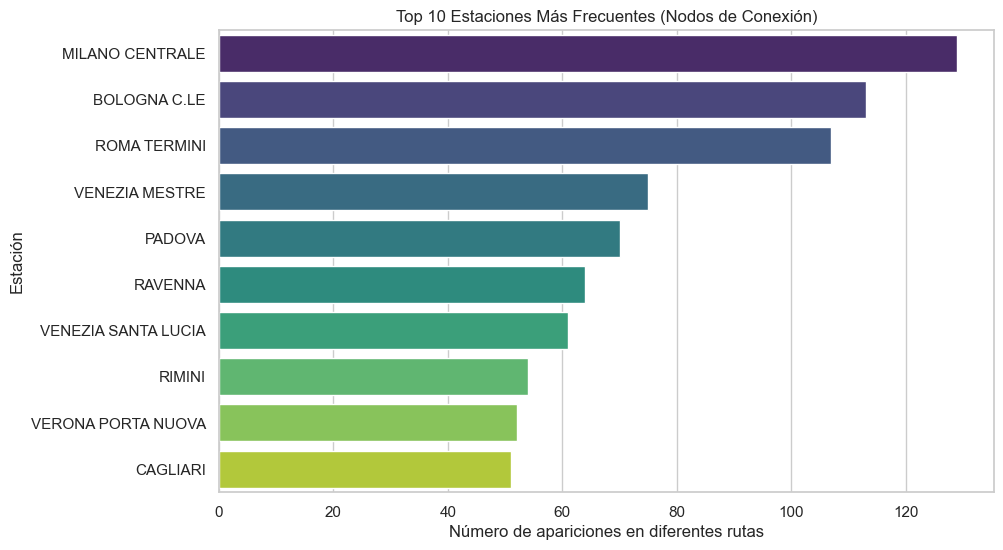

In [35]:
# Gráfico de las 10 estaciones con mayor tráfico o apariciones en rutas
plt.figure(figsize=(10, 6))
top_stations = df['station_name'].value_counts().head(10)
sns.barplot(x=top_stations.values, y=top_stations.index, palette='viridis')
plt.title('Top 10 Estaciones Más Frecuentes (Nodos de Conexión)')
plt.xlabel('Número de apariciones en diferentes rutas')
plt.ylabel('Estación')
plt.show()

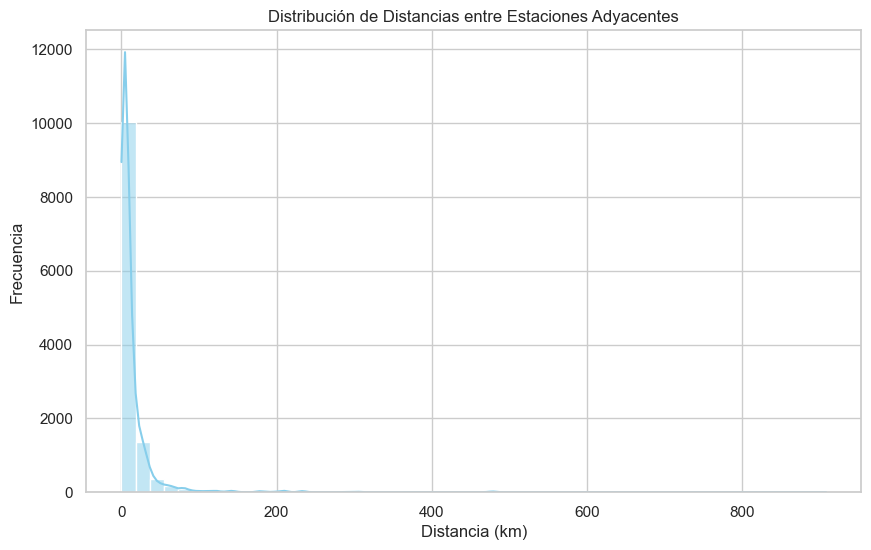

Estadísticas descriptivas de las distancias:
count    12167.000000
mean        12.947064
std         28.803792
min          0.000000
25%          2.542500
50%          6.010000
75%         12.800000
max        908.000000
Name: distance, dtype: float64


In [36]:
# Histograma para ver a qué distancia suelen estar las estaciones entre sí
plt.figure(figsize=(10, 6))
sns.histplot(df['distance'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de Distancias entre Estaciones Adyacentes')
plt.xlabel('Distancia (km)')
plt.ylabel('Frecuencia')
plt.show()

# Estadísticas descriptivas de las distancias
print("Estadísticas descriptivas de las distancias:")
print(df['distance'].describe())

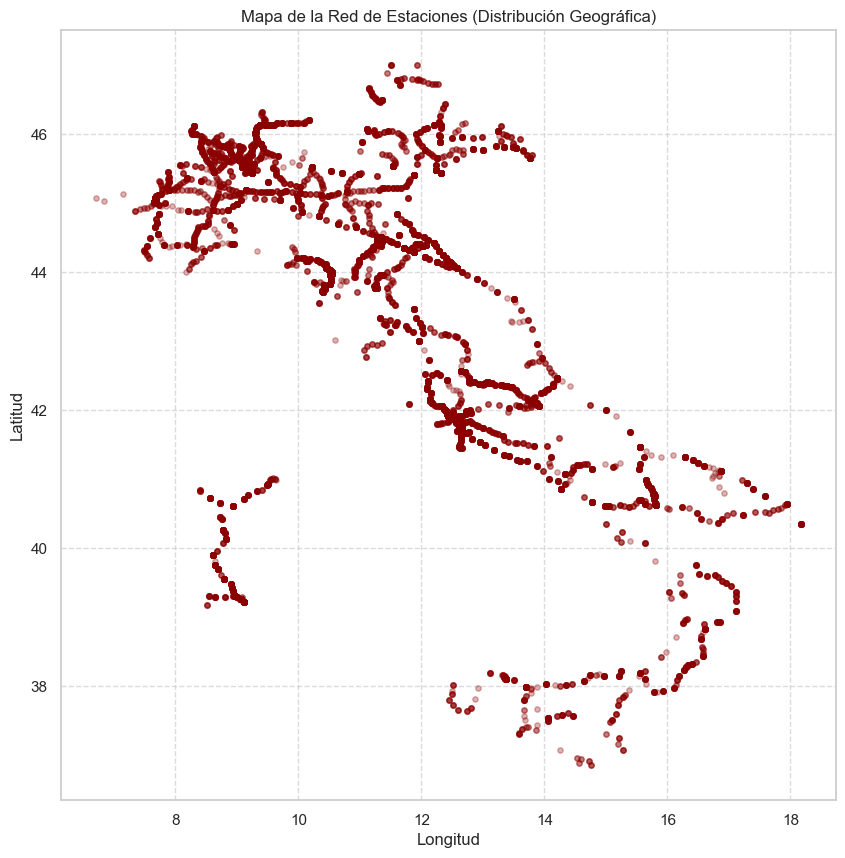

In [37]:
# Gráfico de dispersión usando latitud y longitud para visualizar la red ferroviaria
plt.figure(figsize=(10, 10))
plt.scatter(df['lon'], df['lat'], alpha=0.3, s=15, c='darkred')
plt.title('Mapa de la Red de Estaciones (Distribución Geográfica)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_94240/3372336061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=route_distances, x='distance', y='train_id', palette='magma')


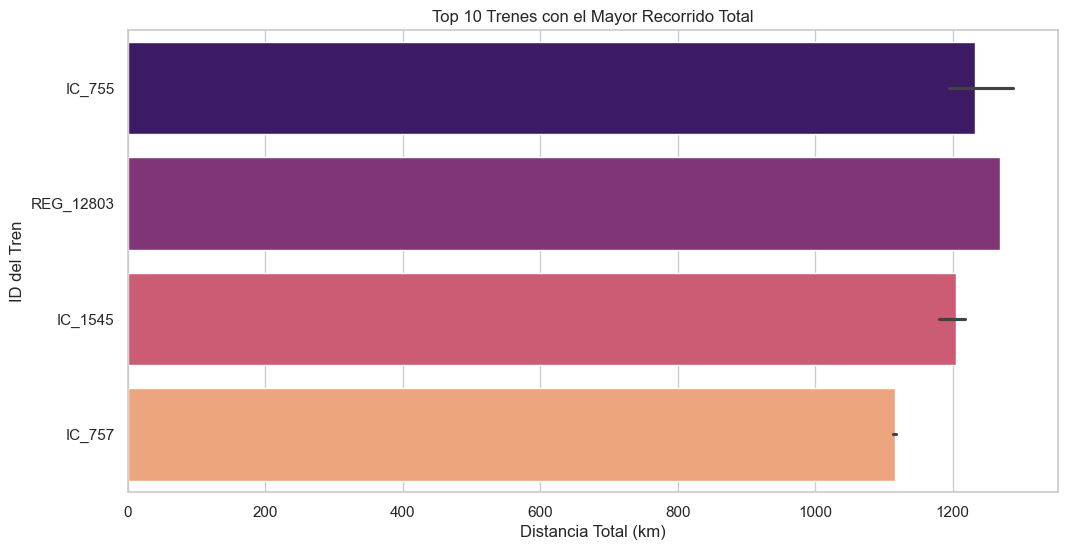

In [38]:
# Agrupamos por ruta/tren para ver cuáles recorren más distancia total
route_distances = df.groupby(['train_id', 'route_id'])['distance'].sum().reset_index()
route_distances = route_distances.sort_values(by='distance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=route_distances, x='distance', y='train_id', palette='magma')
plt.title('Top 10 Trenes con el Mayor Recorrido Total')
plt.xlabel('Distancia Total (km)')
plt.ylabel('ID del Tren')
plt.show()

## Train_fault_information

Tras revisar el archivo, he visto que contiene 113 registros de incidentes ferroviarios. Las columnas principales son:

- date: Fecha del incidente.

- line: Línea ferroviaria afectada (ej. "Milan - Genoa", "Venice - Milan").

- delay_reason: Razón detallada del retraso, incluyendo avisos, el progreso de las reparaciones y los trenes afectados.

- delay_duration: Duración del retraso expresada en texto (por ejemplo, "40 min").

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Configuración de estilo visual para los gráficos
sns.set_theme(style="whitegrid")

In [40]:
# 1. Cargar los datos con la codificación corregida
df = pd.read_csv('Train_fault_information.csv', encoding='latin1')

# Inspección inicial
display(df.head(3))
display(df.info())

# 2. Limpieza de datos
# Convertir la columna 'date' a formato datetime
df['date'] = pd.to_datetime(df['date'])

# Extraer el valor numérico de los minutos de la columna 'delay_duration'
df['delay_minutes'] = df['delay_duration'].str.extract(r'(\d+)').astype(float)

# Eliminar espacios en blanco sobrantes alrededor de los nombres de las líneas
df['line'] = df['line'].str.strip()

print("Datos limpios y listos para el análisis.")

,date,line,delay_reason,delay_duration
0,2024/9/20,Milan - Genoa,Notices of 20/09/2024 Trenitalia RFI Linea Mil...,40 min
1,2024/9/20,High Speed ??Rome - Naples,VIA: RFI Line: from 19:30 Return Returned Rail...,60 min
2,2024/9/20,Genoa - Ventimiglia,Via: RFI Line: from 18:30 Return Ronoro Return...,40 min


<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   date            113 non-null    str  
 1   line            101 non-null    str  
 2   delay_reason    113 non-null    str  
 3   delay_duration  81 non-null     str  
dtypes: str(4)
memory usage: 3.7 KB


None

Datos limpios y listos para el análisis.


In [41]:
# 1. Calcular la cantidad y el porcentaje de nulos por columna
total_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().mean() * 100)

# 2. Crear una tabla resumen para visualizarlo claramente
resumen_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# 3. Ordenar la tabla para ver primero las columnas con más faltantes
resumen_nulos = resumen_nulos.sort_values(by='Porcentaje (%)', ascending=False)

# 4. Mostrar el resultado formateado
display(resumen_nulos.style.format({'Porcentaje (%)': '{:.2f}%'}))

,Total Nulos,Porcentaje (%)
delay_minutes,32,28.32%
delay_duration,32,28.32%
line,12,10.62%
date,0,0.00%
delay_reason,0,0.00%


/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_94240/3741414010.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_lines.values, y=top_lines.index, palette='flare')


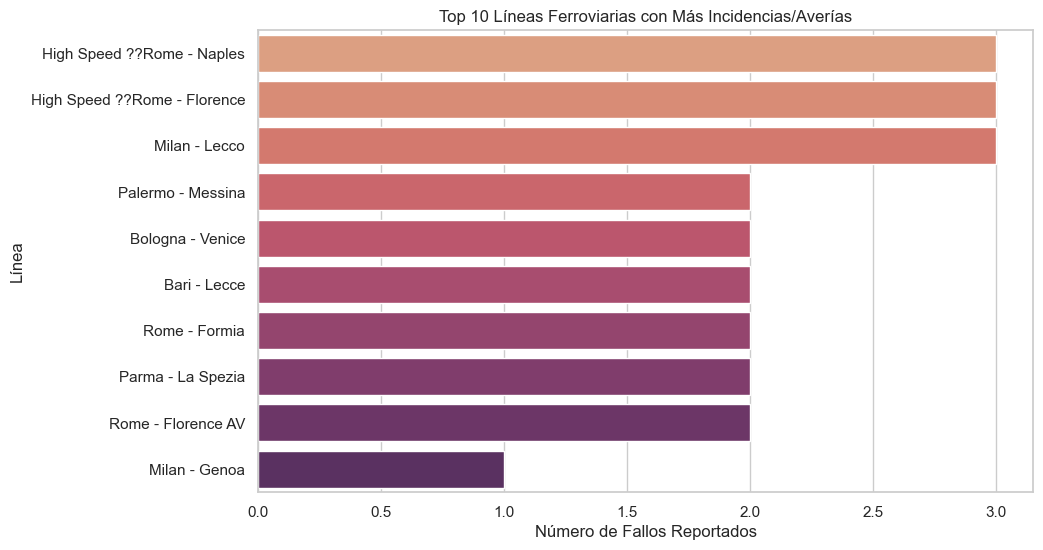

In [42]:
plt.figure(figsize=(10, 6))
# Contar el número de incidencias por línea
top_lines = df['line'].value_counts().head(10)

sns.barplot(x=top_lines.values, y=top_lines.index, palette='flare')
plt.title('Top 10 Líneas Ferroviarias con Más Incidencias/Averías')
plt.xlabel('Número de Fallos Reportados')
plt.ylabel('Línea')
plt.show()

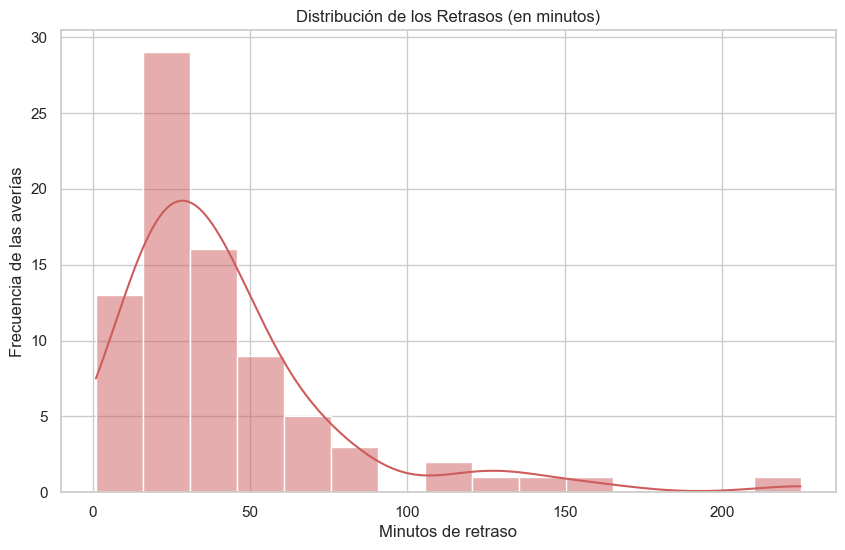

Estadísticas de los retrasos (en minutos):
count     81.000000
mean      43.098765
std       36.579231
min        1.000000
25%       20.000000
50%       30.000000
75%       50.000000
max      225.000000
Name: delay_minutes, dtype: float64


In [43]:
plt.figure(figsize=(10, 6))

# Filtramos los nulos en delay_minutes antes de graficar
delays = df['delay_minutes'].dropna()

sns.histplot(delays, bins=15, kde=True, color='indianred')
plt.title('Distribución de los Retrasos (en minutos)')
plt.xlabel('Minutos de retraso')
plt.ylabel('Frecuencia de las averías')
plt.show()

print("Estadísticas de los retrasos (en minutos):")
print(delays.describe())

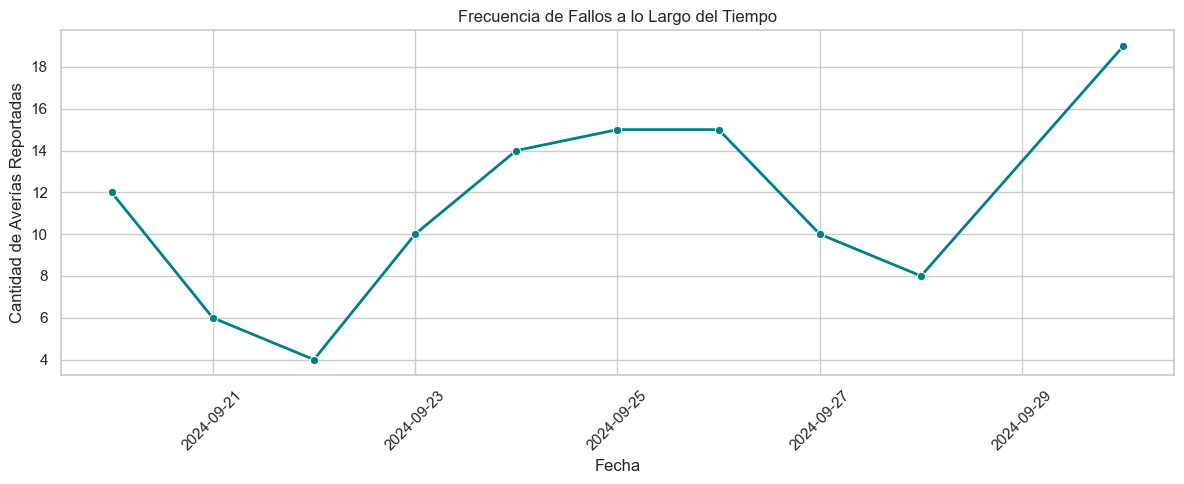

In [44]:
plt.figure(figsize=(12, 5))

# Contar cuántas averías ocurrieron cada día
daily_faults = df.groupby('date').size()

# Crear un gráfico de líneas
sns.lineplot(x=daily_faults.index, y=daily_faults.values, marker='o', color='teal', linewidth=2)

plt.title('Frecuencia de Fallos a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Averías Reportadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Train_station_locations_data

Al revisar este archivo, he detectado que contiene 2,976 registros, lo que corresponde al inventario general de las estaciones de tren en toda Italia (y posiblemente fronteras). Sus columnas son bastante directas:

- name y name_short: Nombres completos y abreviados de cada estación.

- station_id: Un identificador único (ej. S05700).

- lat y lon: Latitud y Longitud geográficas de las estaciones.

- id_region: Un código numérico para identificar la región administrativa en la que se ubica.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo visual
sns.set_theme(style="whitegrid")

In [46]:
# 1. Cargar el archivo de estaciones
df_stations = pd.read_csv('Train_station_locations_data.csv', encoding='latin1')

# 2. Inspección rápida
display(df_stations.head())
display(df_stations.info())

# 3. Limpieza: Eliminar filas que no tengan coordenadas (por seguridad)
df_stations = df_stations.dropna(subset=['lat', 'lon'])

print(f"Total de estaciones válidas para mapear: {len(df_stations)}")

,name,station_id,name_short,lat,lon,id_region
0,ABANO TERME,S05700,Abano Terme,45.355199,11.811533,5.0
1,ABBADIA LARIANA,S01416,Abbadia Lariana,45.895864,9.335175,3.0
2,ABBASANTA,S12873,Abbasanta,40.128801,8.817733,20.0
3,ABBIATEGRASSO,S01062,Abbiategrasso,45.400631,8.921305,3.0
4,ACATE,S12409,Acate,36.996592,14.425450,19.0


<class 'pandas.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        2976 non-null   str    
 1   station_id  2976 non-null   str    
 2   name_short  2975 non-null   str    
 3   lat         2976 non-null   float64
 4   lon         2976 non-null   float64
 5   id_region   2955 non-null   float64
dtypes: float64(3), str(3)
memory usage: 139.6 KB


None

Total de estaciones válidas para mapear: 2976


In [47]:
# 1. Calcular la cantidad y el porcentaje de nulos por columna
total_nulos = df_stations.isnull().sum()
porcentaje_nulos = (df_stations.isnull().mean() * 100)

# 2. Crear una tabla resumen para visualizarlo claramente
resumen_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# 3. Ordenar la tabla para ver primero las columnas con más faltantes
resumen_nulos = resumen_nulos.sort_values(by='Porcentaje (%)', ascending=False)

# 4. Mostrar el resultado formateado
display(resumen_nulos.style.format({'Porcentaje (%)': '{:.2f}%'}))

,Total Nulos,Porcentaje (%)
id_region,21,0.71%
name_short,1,0.03%
station_id,0,0.00%
name,0,0.00%
lat,0,0.00%
lon,0,0.00%


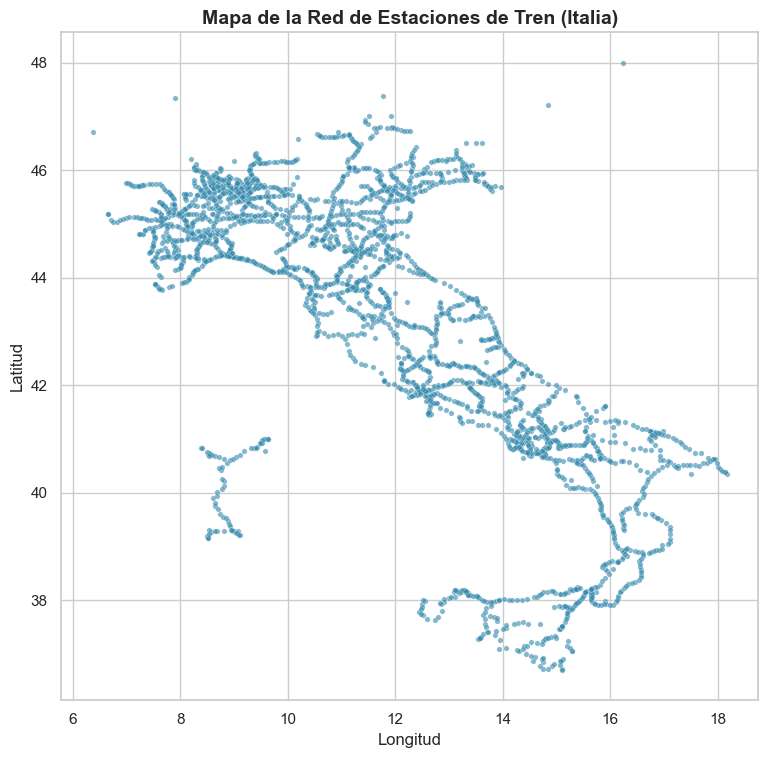

In [19]:
plt.figure(figsize=(9, 11))

# Gráfico de dispersión para usar latitud y longitud como ejes
plt.scatter(
    df_stations['lon'], 
    df_stations['lat'], 
    alpha=0.6, 
    s=15, 
    c='#2E86AB',        # Azul oscuro
    edgecolors='white', # Bordes blancos para que los puntos no se empasten
    linewidth=0.3
)

plt.title('Mapa de la Red de Estaciones de Tren (Italia)', fontsize=14, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)

# Ajustar las proporciones de los ejes para que el "mapa" no se vea achatado
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

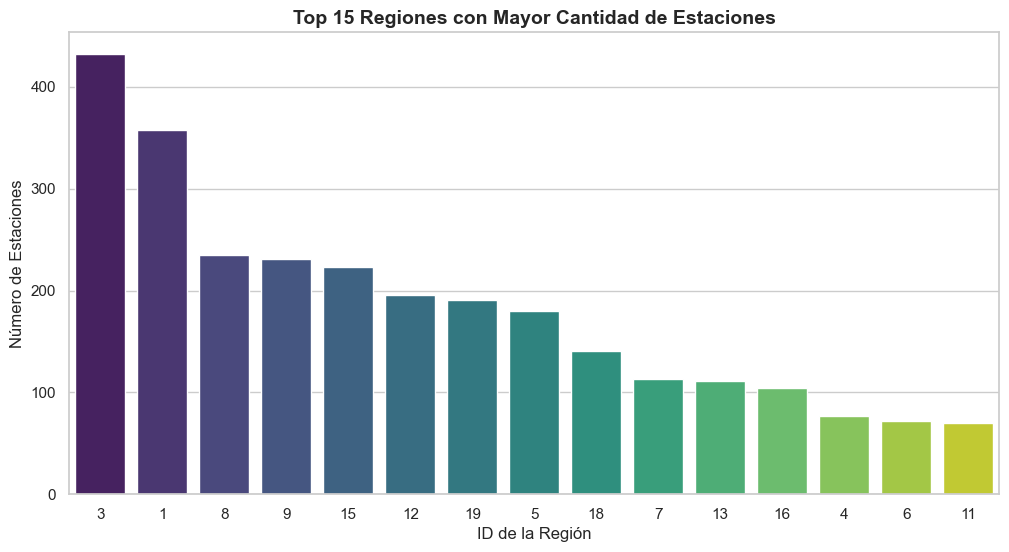

La región con el ID 3.0 es la que tiene más estaciones, con un total de 432.


In [20]:
plt.figure(figsize=(12, 6))

# Contar estaciones por cada 'id_region'
# Quitamos los nulos (si hay) y contamos
region_counts = df_stations['id_region'].dropna().value_counts().head(15)

# Convertir el ID de la región a entero para que se vea mejor en el gráfico
region_index = region_counts.index.astype(int).astype(str)

# Si tienes Seaborn actualizado, usa hue para evitar advertencias de color
sns.barplot(
    x=region_index, 
    y=region_counts.values, 
    hue=region_index, 
    palette='viridis', 
    legend=False
)

plt.title('Top 15 Regiones con Mayor Cantidad de Estaciones', fontsize=14, fontweight='bold')
plt.xlabel('ID de la Región', fontsize=12)
plt.ylabel('Número de Estaciones', fontsize=12)
plt.show()

# Resumen de estadísticas
print(f"La región con el ID {region_counts.index[0]} es la que tiene más estaciones, con un total de {int(region_counts.values[0])}.")

## Train_operation_data

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración del estilo visual
sns.set_theme(style="whitegrid")

In [ ]:
# 1. Cargar el dataset
# Nota: Al ser de 577 MB, puede tardar unos segundos en cargar.
df_ops = pd.read_csv('Train_operation_data.csv')

print("Datos cargados. Filas y columnas:", df_ops.shape)

# 2. Limpieza de datos: Convertir columnas de retrasos a numéricas
# Usamos errors='coerce' para que cualquier texto raro (ej. "CANCELLED") se vuelva NaN (nulo)
cols_to_numeric = ['initial_delay', 'final_delay', 'arrival_delay', 'departure_delay']

for col in cols_to_numeric:
    df_ops[col] = pd.to_numeric(df_ops[col], errors='coerce')

# Convertir la fecha a formato datetime
df_ops['date'] = pd.to_datetime(df_ops['date'])

display(df_ops[['train_class', 'arrival_delay', 'weather', 'holiday']].head())
print("Limpieza completada.")

Datos cargados. Filas y columnas: (2678291, 30)


,train_class,arrival_delay,weather,holiday
0,EC,NaN,cloudy,True
1,EC,3.0,cloudy,True
2,EC,-1.0,cloudy,True
3,EC,NaN,moderate snow,True
4,EC,0.0,heavy snow,True


Limpieza completada.


In [50]:
# 2. Inspección rápida
display(df_ops.head())
display(df_ops.info())

,train_class,train_number,first_station_name,final_station_name,scheduled_departure_station,scheduled_arrival_station,fault_describe,initial_delay,final_delay,date,...,actual_arrival_time,actual_departure_time,actual_running_time,actual_stop_time,week,holiday,temperature_min,temperature_max,weather,wind_speed
0,EC,150,MILANO CENTRALE,CHIASSO,NaN,NaN,NaN,1.0,-1.0,2024-01-01,...,11:11,11:11,0.0,0.0,1,True,0.7,8.7,cloudy,12.0
1,EC,150,MILANO CENTRALE,CHIASSO,NaN,NaN,NaN,1.0,-1.0,2024-01-01,...,11:50,11:54,39.0,4.0,1,True,2.8,11.3,cloudy,13.3
2,EC,150,MILANO CENTRALE,CHIASSO,NaN,NaN,NaN,1.0,-1.0,2024-01-01,...,11:57,11:57,3.0,0.0,1,True,2.8,11.3,cloudy,13.3
3,EC,184,BOLZANO,BRENNERO,NaN,NaN,NaN,0.0,7.0,2024-01-01,...,7:50,7:50,0.0,0.0,1,True,-3.2,8.2,moderate snow,5.6
4,EC,184,BOLZANO,BRENNERO,NaN,NaN,NaN,0.0,7.0,2024-01-01,...,8:16,8:19,26.0,3.0,1,True,-2.3,5.8,heavy snow,6.4


<class 'pandas.DataFrame'>
RangeIndex: 2678291 entries, 0 to 2678290
Data columns (total 30 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   train_class                  str           
 1   train_number                 int64         
 2   first_station_name           str           
 3   final_station_name           str           
 4   scheduled_departure_station  str           
 5   scheduled_arrival_station    str           
 6   fault_describe               str           
 7   initial_delay                float64       
 8   final_delay                  float64       
 9   date                         datetime64[us]
 10  train_id                     str           
 11  station_name                 str           
 12  arrival_delay                float64       
 13  departure_delay              float64       
 14  scheduled_arrival_time       str           
 15  scheduled_departure_time     str           
 16  next_day   

None

Columnas disponibles: ['initial_delay', 'final_delay']


,initial_delay,final_delay
0,1.0,-1.0
1,1.0,-1.0
2,1.0,-1.0
3,0.0,7.0
4,0.0,7.0


<class 'pandas.DataFrame'>
RangeIndex: 2678291 entries, 0 to 2678290
Data columns (total 2 columns):
 #   Column         Dtype  
---  ------         -----  
 0   initial_delay  float64
 1   final_delay    float64
dtypes: float64(2)
memory usage: 40.9 MB


None

Missing (cantidad y %):


,missing,%
initial_delay,16241,0.606394
final_delay,16241,0.606394


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
initial_delay,2662050.0,2.159949,3.773563,-8.0,0.0,0.0,1.0,1.0,2.0,7.0,16.0,183.0
final_delay,2662050.0,1.590896,7.149467,-66.0,-8.0,-4.0,-1.0,1.0,3.0,11.0,29.0,308.0


initial_delay: negativos=991, ceros=379,229, >30min=6,862, >120min=136
final_delay: negativos=1,003,326, ceros=310,345, >30min=22,853, >120min=615
Correlación initial vs final: 0.42184305290168445


count    2.662050e+06
mean    -5.690528e-01
std      6.526322e+00
min     -1.750000e+02
25%     -3.000000e+00
50%     -1.000000e+00
75%      1.000000e+00
max      3.060000e+02
Name: delta_final_minus_initial, dtype: float64

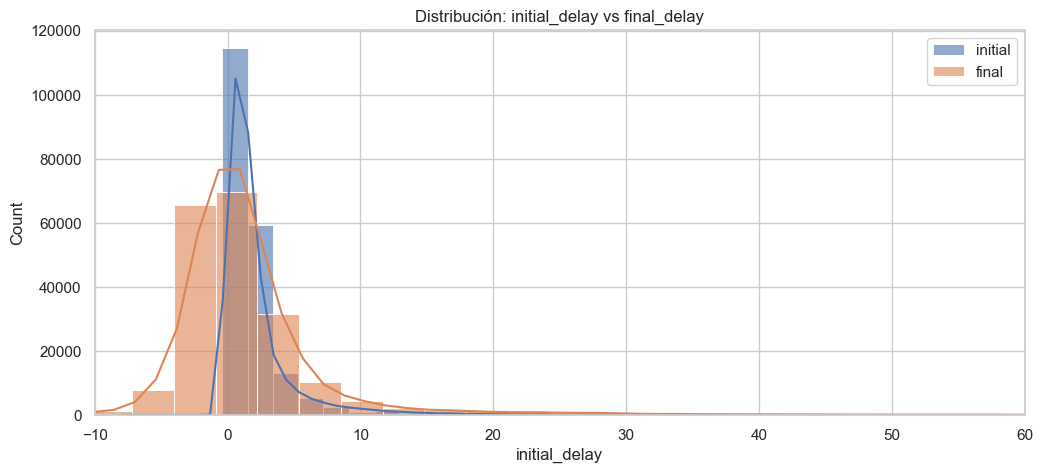

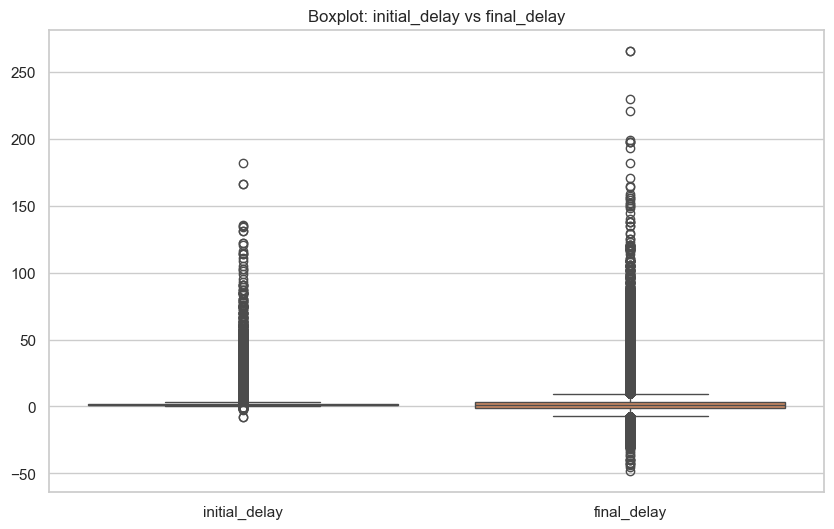

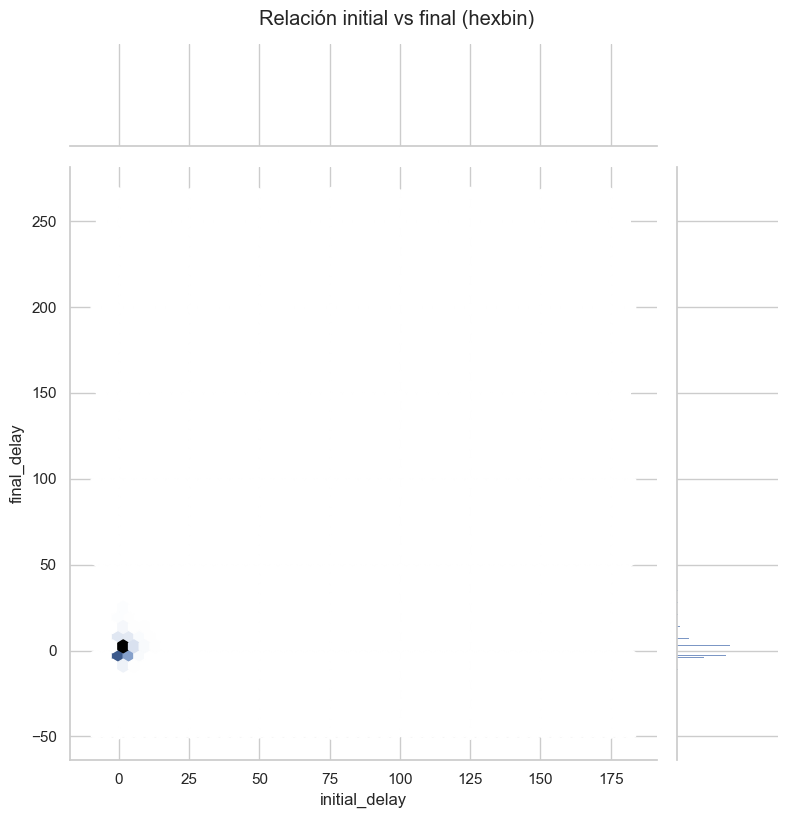

,train_id,date,initial_delay,final_delay,delta_final_minus_initial
2538548,FA_8314,2024-06-21,2.0,308.0,306.0
2538550,FA_8314,2024-06-21,2.0,308.0,306.0
2538551,FA_8314,2024-06-21,2.0,308.0,306.0
2538552,FA_8314,2024-06-21,2.0,308.0,306.0
2538553,FA_8314,2024-06-21,2.0,308.0,306.0
2538547,FA_8314,2024-06-21,2.0,308.0,306.0
2538554,FA_8314,2024-06-21,2.0,308.0,306.0
2538549,FA_8314,2024-06-21,2.0,308.0,306.0
418,FR_9802,2024-01-01,8.0,266.0,258.0
419,FR_9802,2024-01-01,8.0,266.0,258.0


In [51]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Asegurar que df_ops está cargado y con columnas numéricas
if 'df_ops' not in globals():
    df_ops = pd.read_csv('Train_operation_data.csv')
    for c in ['initial_delay','final_delay','arrival_delay','departure_delay']:
        if c in df_ops.columns:
            df_ops[c] = pd.to_numeric(df_ops[c], errors='coerce')
    if 'date' in df_ops.columns:
        df_ops['date'] = pd.to_datetime(df_ops['date'], errors='coerce')

cols = [c for c in ['initial_delay', 'final_delay'] if c in df_ops.columns]
print("Columnas disponibles:", cols)

# Vista rápida y info
display(df_ops[cols].head())
display(df_ops[cols].info())

# Missing y proporciones
missing = df_ops[cols].isnull().sum()
pct_missing = (missing / len(df_ops)) * 100
print("Missing (cantidad y %):")
display(pd.concat([missing.rename('missing'), pct_missing.rename('%')], axis=1))

# Estadísticas descriptivas con percentiles extremos
display(df_ops[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

# Conteos de negativos/ceros/umbral
for c in cols:
    s = df_ops[c].dropna()
    print(f"{c}: negativos={(s<0).sum():,}, ceros={(s==0).sum():,}, >30min={(s>30).sum():,}, >120min={(s>120).sum():,}")

# Delta final - initial y correlación
if set(['initial_delay','final_delay']).issubset(df_ops.columns):
    df_ops['delta_final_minus_initial'] = df_ops['final_delay'] - df_ops['initial_delay']
    print("Correlación initial vs final:",
          df_ops[['initial_delay','final_delay']].corr().iloc[0,1])
    display(df_ops['delta_final_minus_initial'].describe())

# Muestras para graficar (evitar sobrecargar memoria)
sample = df_ops[cols].dropna()
max_plot = 200000
if len(sample) > max_plot:
    sample = sample.sample(max_plot, random_state=42)

# Histogramas comparativos
plt.figure(figsize=(12,5))
sns.histplot(sample['initial_delay'], bins=100, color='C0', label='initial', kde=True, stat='count', alpha=0.6)
sns.histplot(sample['final_delay'], bins=100, color='C1', label='final', kde=True, stat='count', alpha=0.6)
plt.legend(); plt.title('Distribución: initial_delay vs final_delay')
# limitar eje x para ver la mayor parte de la distribución (ajustable)
xmax = max(sample.quantile(0.995).max(), 60)
plt.xlim(-10, xmax)
plt.show()

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=sample[cols], palette=['C0','C1'])
plt.title('Boxplot: initial_delay vs final_delay')
plt.show()

# Jointplot / hexbin para relación entre las dos columnas
if not sample.empty:
    sns.jointplot(x='initial_delay', y='final_delay', data=sample, kind='hex', height=8)
    plt.suptitle('Relación initial vs final (hexbin)', y=1.02)
    plt.show()

# Mostrar los casos más extremos
extreme = df_ops.sort_values(by='final_delay', ascending=False).head(20)
display(extreme[['train_id', 'date', 'initial_delay', 'final_delay', 'delta_final_minus_initial']].head(20))
# ...existing code...

In [29]:
import pandas as pd

# Asumiendo que ya tienes cargado el dataset del paso anterior:
# df_ops = pd.read_csv('Train_operation_data.csv')

# 1. Calcular nulos, no nulos y el porcentaje
total_nulos = df_ops.isnull().sum()
total_no_nulos = df_ops.notnull().sum()
porcentaje_nulos = (total_nulos / len(df_ops)) * 100

# 2. Crear un DataFrame estructurado para visualizarlo fácilmente
resumen_nulos = pd.DataFrame({
    'Total No Nulos (Con Datos)': total_no_nulos,
    'Total Nulos (NaNs)': total_nulos,
    'Porcentaje Nulo (%)': porcentaje_nulos
})

# Ordenar para ver primero las columnas con MÁS datos faltantes
resumen_nulos = resumen_nulos.sort_values(by='Porcentaje Nulo (%)', ascending=False)

# Mostrar la tabla formateando el porcentaje
print(f"Total de filas en el dataset: {len(df_ops):,}")
display(resumen_nulos.style.format({'Porcentaje Nulo (%)': '{:.2f}%', 'Total No Nulos (Con Datos)': '{:,}', 'Total Nulos (NaNs)': '{:,}'}))

Total de filas en el dataset: 2,678,291


,Total No Nulos (Con Datos),Total Nulos (NaNs),Porcentaje Nulo (%)
fault_describe,"8,071","2,670,220",99.70%
scheduled_departure_station,"8,283","2,670,008",99.69%
scheduled_arrival_station,"8,283","2,670,008",99.69%
arrival_delay,"2,318,426","359,865",13.44%
departure_delay,"2,318,509","359,782",13.43%
actual_stop_time,"2,661,012","17,279",0.65%
actual_running_time,"2,661,012","17,279",0.65%
actual_arrival_time,"2,661,013","17,278",0.65%
actual_departure_time,"2,661,013","17,278",0.65%
initial_delay,"2,662,050","16,241",0.61%


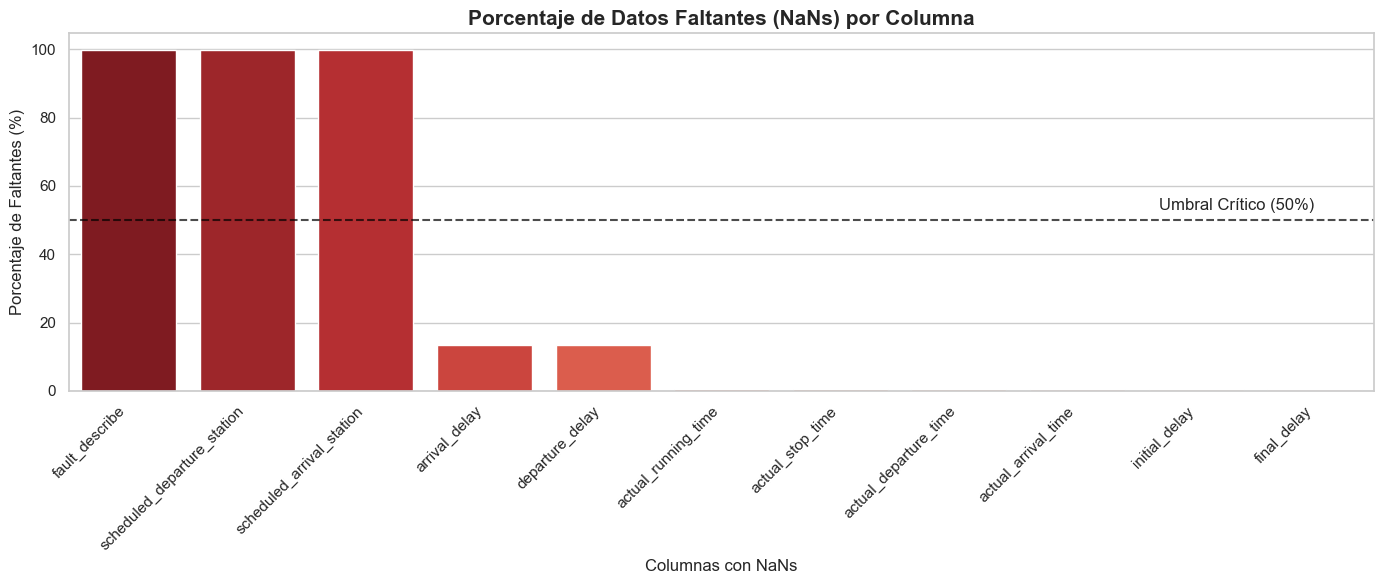

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Filtramos para graficar solo las columnas que tienen al menos un valor nulo
cols_con_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

if not cols_con_nulos.empty:
    # Usamos un mapa de colores rojo para resaltar el "peligro" de los datos faltantes
    sns.barplot(
        x=cols_con_nulos.index, 
        y=cols_con_nulos.values, 
        hue=cols_con_nulos.index,
        palette='Reds_r',
        legend=False
    )
    
    plt.title('Porcentaje de Datos Faltantes (NaNs) por Columna', fontsize=15, fontweight='bold')
    plt.xlabel('Columnas con NaNs', fontsize=12)
    plt.ylabel('Porcentaje de Faltantes (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Añadir una línea roja horizontal si quieres marcar un umbral (ej. 50% de nulos)
    plt.axhline(y=50, color='black', linestyle='--', alpha=0.7)
    plt.text(len(cols_con_nulos)-1, 52, 'Umbral Crítico (50%)', ha='right', va='bottom')
    
    plt.tight_layout()
    plt.show()
else:
    print("¡Excelente noticia! Tu dataset no tiene ningún valor nulo (NaN). Está 100% completo.")

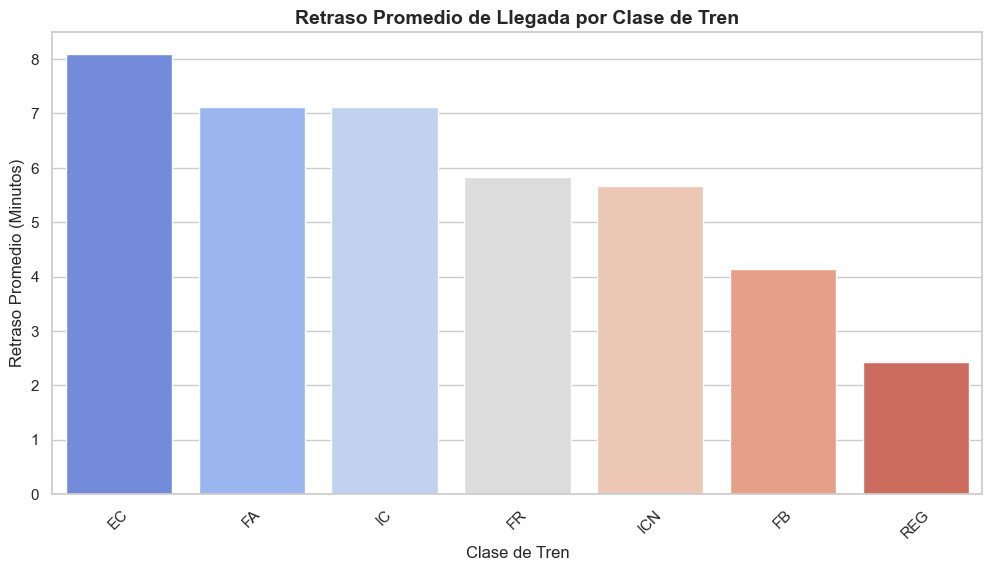

In [25]:
plt.figure(figsize=(12, 6))

# Agrupar por clase de tren y calcular el retraso medio de llegada
delay_by_class = df_ops.groupby('train_class')['arrival_delay'].mean().sort_values(ascending=False)

# Usamos hue y legend=False para evitar el FutureWarning de Seaborn
sns.barplot(
    x=delay_by_class.index, 
    y=delay_by_class.values, 
    hue=delay_by_class.index, 
    palette='coolwarm', 
    legend=False
)

plt.title('Retraso Promedio de Llegada por Clase de Tren', fontsize=14, fontweight='bold')
plt.xlabel('Clase de Tren', fontsize=12)
plt.ylabel('Retraso Promedio (Minutos)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

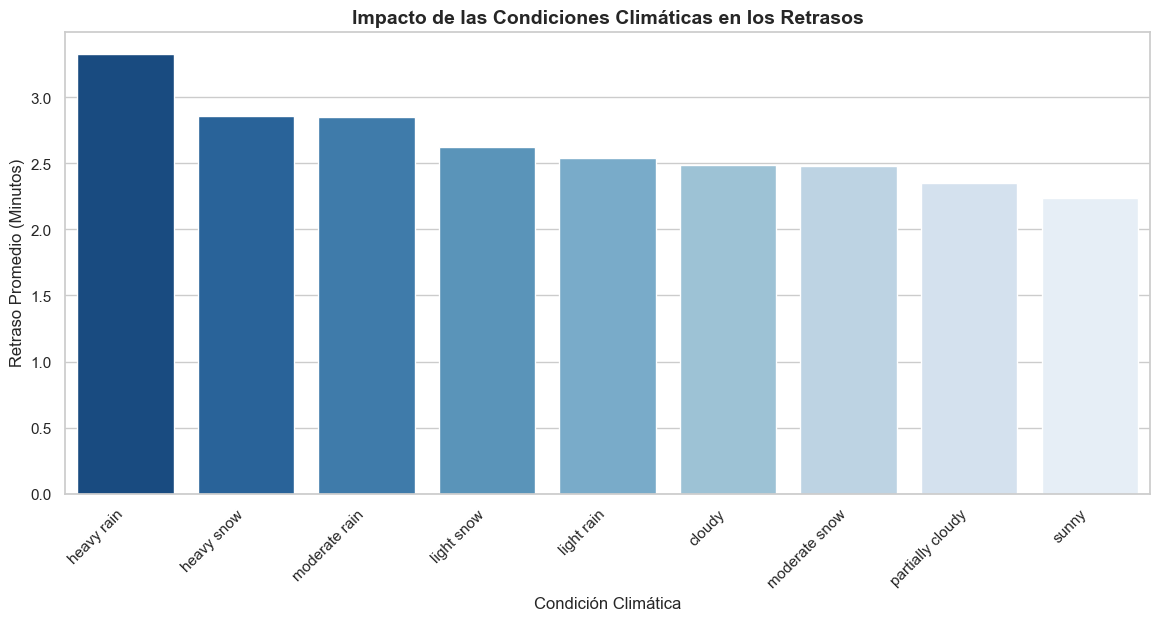

In [26]:
plt.figure(figsize=(14, 6))

# Filtramos climas que tengan al menos 1000 registros para no sesgar por casos aislados
weather_counts = df_ops['weather'].value_counts()
valid_weathers = weather_counts[weather_counts > 1000].index

df_weather = df_ops[df_ops['weather'].isin(valid_weathers)]

# Calculamos el promedio de retraso por clima
delay_by_weather = df_weather.groupby('weather')['arrival_delay'].mean().sort_values(ascending=False)

sns.barplot(
    x=delay_by_weather.index, 
    y=delay_by_weather.values, 
    hue=delay_by_weather.index, 
    palette='Blues_r', 
    legend=False
)

plt.title('Impacto de las Condiciones Climáticas en los Retrasos', fontsize=14, fontweight='bold')
plt.xlabel('Condición Climática', fontsize=12)
plt.ylabel('Retraso Promedio (Minutos)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

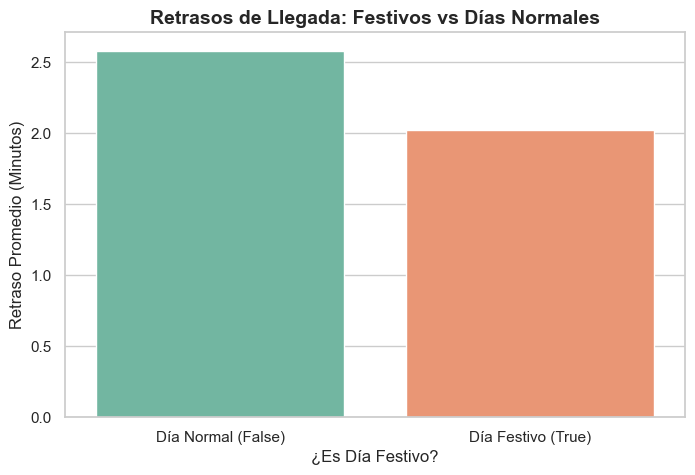

In [27]:
plt.figure(figsize=(8, 5))

# Calculamos el retraso promedio dependiendo de si es festivo o no
delay_holiday = df_ops.groupby('holiday')['arrival_delay'].mean()

sns.barplot(
    x=delay_holiday.index, 
    y=delay_holiday.values, 
    hue=delay_holiday.index, 
    palette='Set2', 
    legend=False
)

plt.title('Retrasos de Llegada: Festivos vs Días Normales', fontsize=14, fontweight='bold')
plt.xlabel('¿Es Día Festivo?', fontsize=12)
plt.ylabel('Retraso Promedio (Minutos)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Día Normal (False)', 'Día Festivo (True)'])
plt.show()

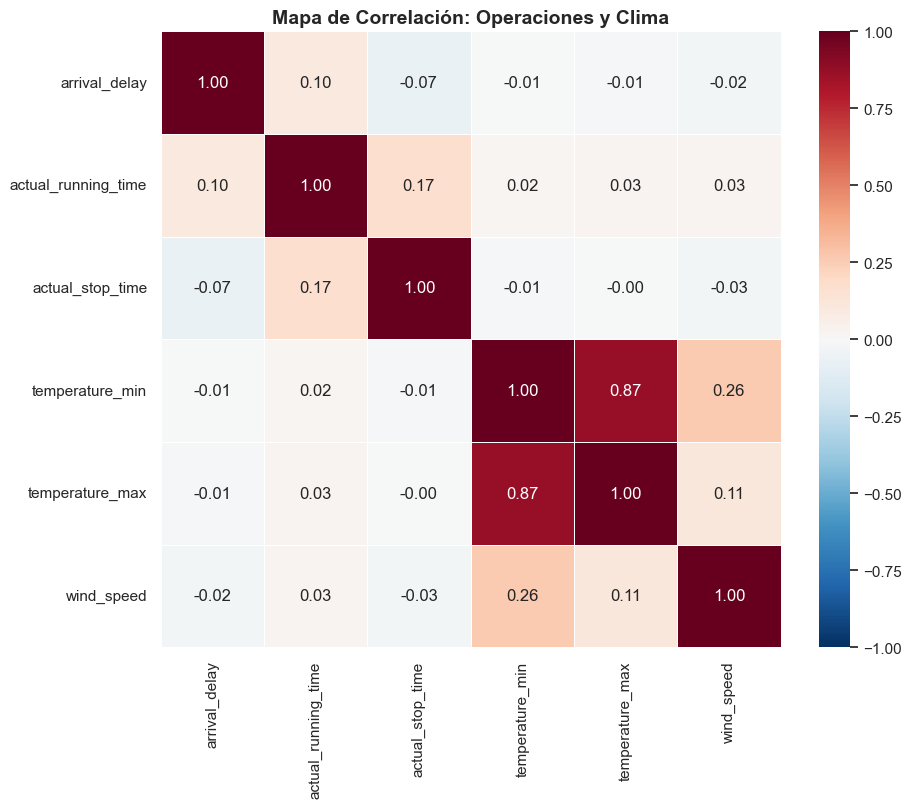

In [28]:
plt.figure(figsize=(10, 8))

# Seleccionamos variables numéricas de interés
num_vars = ['arrival_delay', 'actual_running_time', 'actual_stop_time', 'temperature_min', 'temperature_max', 'wind_speed']
corr_matrix = df_ops[num_vars].corr()

# Generamos el mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Mapa de Correlación: Operaciones y Clima', fontsize=14, fontweight='bold')
plt.show()